<a href="https://colab.research.google.com/github/mish0410/netflix-data-analysis/blob/main/Nf_BS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement
Netflix is a global streaming platform with a user base of 222M as of mid 2021. The company would like to understand from its data (1925- mid 2021) how can they grow their business further.

This can be achieved by analysing the data to find patterns, in demand content and taking an informed decision on which type of content the company should focus on producing, genre and rating wise production trend. apart from that we should also analyse country specific trends to curate content to fit specific consumer needs hence driving business growth

#Data load

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('Netflix.csv')

## Data overview

### Subtask:
Display the first few rows, check the data types, and get a summary of the dataset's structure.


**Reasoning**:
Display the first few rows, data types, and shape of the dataframe to understand its structure.



In [ ]:
display(df.head())
df.info()
print("shape of the data is:", df.shape)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
shape of the data is: (8807, 12)


## Missing values

### Subtask:
Identify and visualize missing values in the dataset.


**Reasoning**:
Calculate the number of missing values for each column and visualize them using a heatmap with annotations.



In [ ]:
missing_value = df.isnull().sum()
print("missing value per column:")
print(missing_value)

missing value per column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


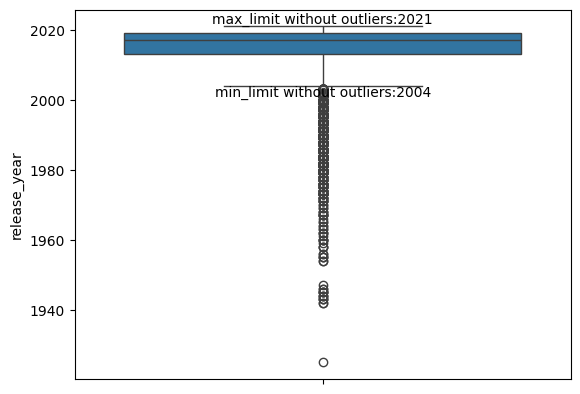

0
1


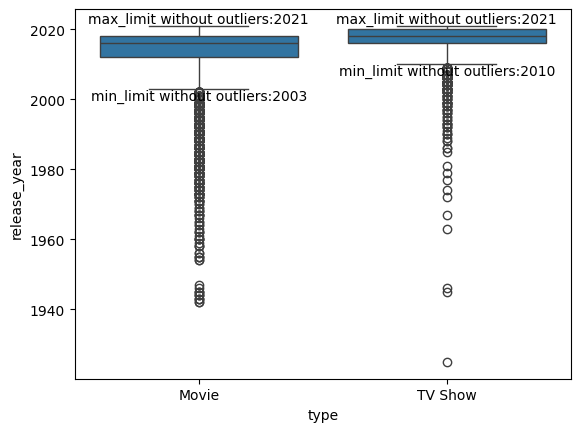

In [ ]:
#outlier check
sns.boxplot(y = df['release_year'])
Q1 = np.percentile(df['release_year'], 25)
Q3 = np.percentile(df['release_year'], 75)
IQR = Q3-Q1
min_range = Q1 - 1.5*IQR
max_range = Q3 + 1.5*IQR
lower_wisk = df['release_year'][df['release_year'] >= min_range].min()
upper_wisk = df['release_year'][df['release_year']<= max_range].max()
plt.text(0,lower_wisk, f'min_limit without outliers:{lower_wisk}', ha = 'center',
         va = 'top')
plt.text(0,upper_wisk, f'max_limit without outliers:{upper_wisk}', ha = 'center',
         va = 'bottom')
plt.show()

#content type wise outlier check
sns.boxplot(y = df['release_year'], x = df['type'])
for i,t in enumerate(df['type'].unique()):
  sub = df[df['type'] == t]['release_year']
  Q1 = np.percentile(sub, 25)
  Q3 = np.percentile(sub, 75)
  IQR = Q3-Q1
  min_range = Q1 - 1.5*IQR
  max_range = Q3 + 1.5*IQR
  lower_wisk = sub[sub >= min_range].min()
  upper_wisk = sub[sub <= max_range].max()
  plt.text(i,lower_wisk, f'min_limit without outliers:{lower_wisk}',
           ha = 'center', va = 'top')
  plt.text(i,upper_wisk, f'max_limit without outliers:{upper_wisk}',
           ha = 'center', va = 'bottom')

plt.ylabel('release_year')
plt.xlabel('type')
plt.show()

In [ ]:
### Insights###
''': Majority of the data related to Movies is concentrated between 2003
    and 2021
   : Majority of the data related to TV Shows is concentrated between 2010
   and 2021
   hence during data analysis we should filter out outlier data to have more
   meaningful insignts'''


In [ ]:
### Dataset bifurcation for Movies and TV shows
movies_df = df[df['type'] == 'Movie']
tv_shows_df = df[df['type'] == 'TV Show']
def data_limit(df, column):
  Q1 = np.percentile(df[column], 25)
  Q3 = np.percentile(df[column], 75)
  IQR = Q3-Q1
  min_range = Q1 - 1.5*IQR
  max_range = Q3 + 1.5*IQR
  min = df[column][df[column] >= min_range].min()
  max = df[column][df[column] <= max_range].max()
  return min,max
movies_min,movies_max = data_limit(movies_df,'release_year')
tv_shows_min,tv_shows_max = data_limit(tv_shows_df,'release_year')

## Summary statistics of whole dataset



### Subtask:
Generate descriptive statistics for numerical and categorical columns.


**Reasoning**:
Generate and display descriptive statistics for numerical and categorical columns as requested by the subtask.



In [ ]:
print('\nDescriptive analysis for all categorical columns is :')
display(df.describe(include = object))


Descriptive analysis for all categorical columns is :


,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


#Data filtering to exclude outliers
since majority of the movies data is concentrated between 2003 and 2021 and tv shows data is concentrated between 2010 and 2021 as proved in earlier steps, it is better to only include data within these date ranges to have more relevant analysis and the same has been demonstrated in below steps

In [ ]:
movies_df = movies_df[(movies_df['release_year'] >= movies_min) &
 (movies_df['release_year'] <= movies_max)]
tv_shows_df = tv_shows_df[(tv_shows_df['release_year'] >= tv_shows_min) &
 (tv_shows_df['release_year'] <= tv_shows_max)]
df = pd.concat([movies_df,tv_shows_df], ignore_index= True)
# Function to unnest a specific column
def unnest_column(df, col):
    return (
        df.assign(**{col: df[col].fillna('').str.split(',\s*')})
          .explode(col)
          .replace('', np.nan)
          .reset_index(drop=True)
    )

# Preprocess for country & genres
unnested_df = unnest_column(df, 'country')
unnested_df = unnest_column(unnested_df, 'listed_in')

           country  day_added  count        pct
0           Canada     Friday    229  27.326969
1           Canada  Wednesday    129  15.393795
2           Canada   Thursday    108  12.887828
3           France     Friday    282  33.691756
4           France   Thursday    111  13.261649
5           France  Wednesday    102  12.186380
6            India   Thursday    535  21.563886
7            India     Friday    446  17.976622
8            India     Monday    389  15.679162
9   United Kingdom     Friday    469  29.166667
10  United Kingdom  Wednesday    226  14.054726
11  United Kingdom   Thursday    222  13.805970
12   United States     Friday   1835  30.954791
13   United States  Wednesday    850  14.338731
14   United States    Tuesday    832  14.035088


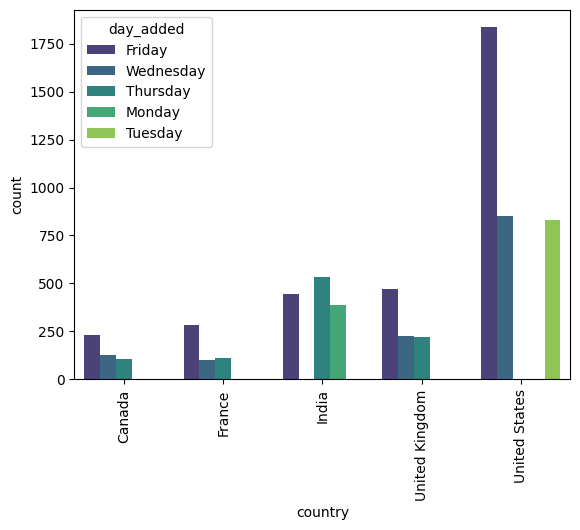

In [ ]:
unnested_df['date_added'] = pd.to_datetime(unnested_df['date_added'],
                                           format = 'mixed')
unnested_df['day_added'] = unnested_df['date_added'].dt.day_name()
unnested_df['day_added'].value_counts()
grouped = (unnested_df.groupby('country')['day_added'].value_counts().
           groupby(level = 0).head(7).reset_index(name = 'count').
           sort_values(by = 'count', ascending = False).reset_index(drop = True))
grouped['pct'] = (grouped['count']/grouped.groupby('country')['count'].
                  transform('sum')*100)
grouped = (grouped.sort_values(by = ['country','count'], ascending = [True,False]).
           groupby('country').head(3).reset_index(drop = True))
top_5_countries = grouped.groupby('country')['count'].sum().nlargest(5).index
grouped = grouped[grouped['country'].isin(top_5_countries)].reset_index(drop = True)
print(grouped.head(15))
sns.barplot(data = grouped, x = 'country', y = 'count', hue = 'day_added',
            palette = 'viridis')
plt.xticks(rotation = 90)
plt.show()


## Visualize distributions

### Subtask:
Plot distributions of key features like 'type', 'release_year', and 'rating'.


**Reasoning**:
Create count plots for 'type' and 'rating', and a distribution plot for 'release_year' to visualize their distributions. Rotate x-axis labels for 'rating' for better readability.



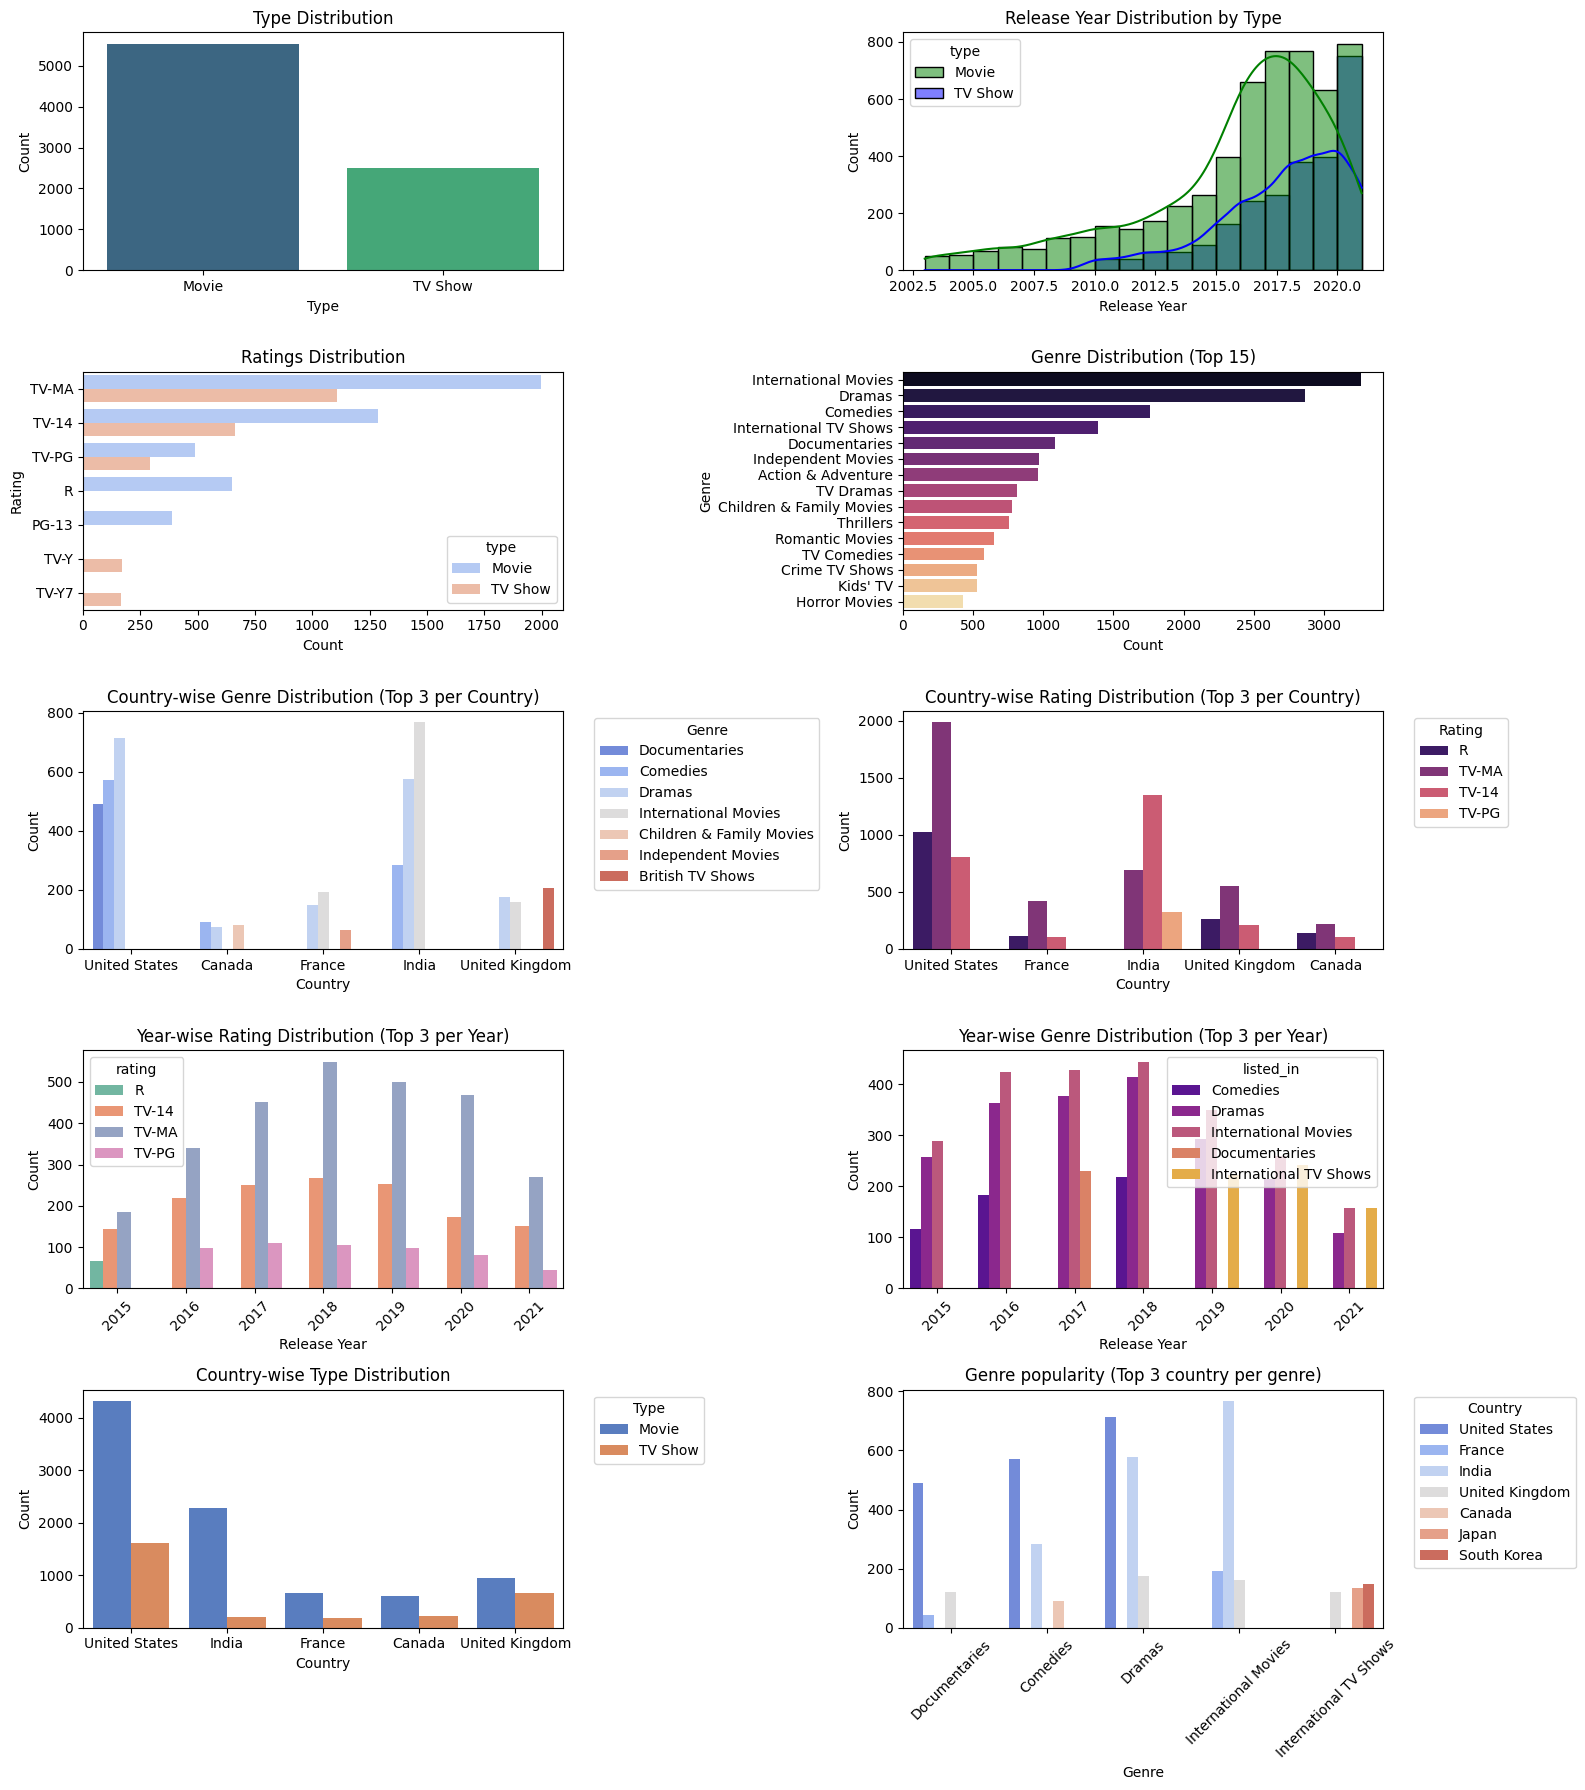

In [ ]:
# --- PLOTTING ---
plt.figure(figsize=(16, 18))

# 1️⃣ Type Distribution
plt.subplot(5, 2, 1)
sns.countplot(x='type', data=df, palette='viridis')
plt.title('Type Distribution')
plt.xlabel('Type')
plt.ylabel('Count')

# 2️⃣ Release Year & Type Distribution (1985–2021)
plt.subplot(5, 2, 2)
sns.histplot(x='release_year', hue='type', data=df, bins=18, kde=True,
             palette=['green', 'blue'])
plt.title('Release Year Distribution by Type')
plt.xlabel('Release Year')
plt.ylabel('Count')

# Helper: top N within group
def top_n_within_group(df, group_col, count_col, n=3):
    return (df.groupby(group_col)[count_col]
              .value_counts()
              .groupby(level=0)
              .head(n)
              .reset_index()
              .rename(columns={0: 'count'}))

# 3️⃣ Ratings Distribution (Descending)
plt.subplot(5, 2, 3)
top_rating_order = top_n_within_group(df, 'type', 'rating', 5)
merged = df.merge(top_rating_order[['type', 'rating']], on=['type', 'rating'])
rating_order = merged['rating'].value_counts().index
sns.countplot(y='rating', hue = 'type', data=merged, order=rating_order,
              palette='coolwarm')
plt.title('Ratings Distribution')
plt.xlabel('Count')
plt.ylabel('Rating')

# 4️⃣ Genre Distribution (Descending)
plt.subplot(5, 2, 4)
genre_order = unnested_df['listed_in'].value_counts().index
sns.countplot(y='listed_in', data=unnested_df, order=genre_order[:15],
              palette='magma')
plt.title('Genre Distribution (Top 15)')
plt.xlabel('Count')
plt.ylabel('Genre')


# 5️⃣ Country-wise Genre Distribution (Top 3 for each country)
plt.subplot(5, 2, 5)
top_genres_per_country = top_n_within_group(unnested_df, 'country',
                                            'listed_in', 3)
merged = unnested_df.merge(top_genres_per_country[['country', 'listed_in']],
                           on=['country', 'listed_in'])
top_countries = unnested_df['country'].value_counts().nlargest(5).index
sns.countplot(x='country', hue='listed_in',
              data=merged[merged['country'].isin(top_countries)],
              palette='coolwarm')
plt.title('Country-wise Genre Distribution (Top 3 per Country)')
plt.xlabel('Country')
plt.ylabel('Count')
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')

# 6️⃣ Country-wise Rating Distribution (Top 3 for each country)
plt.subplot(5, 2, 6)
top_ratings_per_country = top_n_within_group(unnested_df, 'country',
                                             'rating', 3)
merged = unnested_df.merge(top_ratings_per_country[['country', 'rating']],
                           on=['country', 'rating'])
sns.countplot(x='country', hue='rating',
              data=merged[merged['country'].isin(top_countries)],
              palette='magma')
plt.title('Country-wise Rating Distribution (Top 3 per Country)')
plt.xlabel('Country')
plt.ylabel('Count')
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')

# 7️⃣ Year-wise Rating Distribution (Top 3 for each year, 2015–2021)
plt.subplot(5, 2, 7)
filtered_years = df[(df['release_year'] >= 2015) & (df['release_year'] <= 2021)]
top_ratings_per_year = top_n_within_group(filtered_years, 'release_year',
                                          'rating', 3)
merged = filtered_years.merge(top_ratings_per_year[['release_year', 'rating']],
                              on=['release_year', 'rating'])
sns.countplot(x='release_year', hue='rating', data=merged, palette='Set2')
plt.title('Year-wise Rating Distribution (Top 3 per Year)')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.xticks(rotation=45)

# 8️⃣ Year-wise Genre Distribution (Top 3 for each year, 2015–2021)
plt.subplot(5, 2, 8)
filtered_years_genre = (unnested_df[(unnested_df['release_year'] >= 2015) &
 (unnested_df['release_year'] <= 2021)])
top_genres_per_year = top_n_within_group(filtered_years_genre,
                                         'release_year', 'listed_in', 3)
merged = filtered_years_genre.merge(top_genres_per_year[
    ['release_year', 'listed_in']], on=['release_year', 'listed_in'])
sns.countplot(x='release_year', hue='listed_in', data=merged, palette='plasma')
plt.title('Year-wise Genre Distribution (Top 3 per Year)')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.xticks(rotation=45)

# 9️⃣ Country-wise Type Distribution
plt.subplot(5, 2, 9)
sns.countplot(x='country', hue='type', data=unnested_df[
    unnested_df['country'].isin(top_countries)], palette='muted')
plt.title('Country-wise Type Distribution')
plt.xlabel('Country')
plt.ylabel('Count')
plt.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# 🔟 Genre-wise Country Distribution (top 3 for each Genre)
plt.subplot(5, 2, 10)
top_genre = unnested_df['listed_in'].value_counts().nlargest(5).index
top_country_per_genre = top_n_within_group(unnested_df[
    unnested_df['listed_in'].isin(top_genre)], 'listed_in', 'country', 3)
merged = unnested_df.merge(top_country_per_genre[
    ['listed_in','country']], on=['listed_in', 'country'])
sns.countplot(x='listed_in', hue='country',
              data=merged[merged['listed_in'].isin(top_genre)],
              palette='coolwarm')
plt.title('Genre popularity (Top 3 country per genre)')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Data Analysis Key Findings

*   The dataset contains 8807 rows and 12 columns.
*   The `release_year` is the only numerical column, while the rest are of `object` type.
*   Several columns have missing values, with `director` having the highest count (2634), followed by `country` (831) and `cast` (825).
*   The `release_year` ranges from 1925 to 2021, with a mean around 2014.
*   Movies are more frequent than TV shows in the dataset.
*   'United States' is the most frequent country and 'TV-MA' is the most frequent rating.
*   International movies, drama and comedies are the most loved genres
*   There is a clear increasing trend in the number of content releases, particularly TV shows, in recent years.

### Business insights

*   Given the substantial number of missing values in `director`, `country`, and `cast`, imputation or strategic handling of these missing values is crucial however since these are categorical data, mathematical imputation might not be the right approach hence i am not imputing these values to preserve authenticity
*   similarly if the cast and director can be linked with revenue or profit data before analysing, company might be able to take bold bets on which cast and directors to be prioritized for content creation based on their previous value generation
*   US audience loves TV-MA rated drama
*   Second most content consumption is in India and indian audience loves international moveies followed by drama and comedy
*   after 2015 top 3 ratings have been TV-MA, TV-14 and TV-PG
*   top 5 genres for majority of the data has been documentary, comedy, drama, international movies, international TV-shows
*   in last 3 years international TV-shows as a genre has shown tremendous growth, and these are very much popular in Asian contries like Japan, South Korea and one exception is UK in west
*   in US 31% of the contents are released on Friday however in India 21% of the content is released on Thursday followed by 18% on Thursday

##Business actionable
*   Company should work on fixing data entry in data table to make stronger insights from data, for example ~25% of values are missing in director's column hence any insight we draw in terms of popular directors/most productive director might have biased output due to data skewness
*   more production of TV-MA might boost growth in US
*   company's focus should be on winning in India as it has immense growth potential since its second in the list of most content consumption hence our focus should be on delivering maximum international movies, drama and comedy content for Indians
*   according to recent trends company's focus should be on consolidating content related to TV-MA, TV-14 and TV-PG ratings and drop other ratings for top consumption countries for sustainable growth
*   Production and content release can be synced with the demand of the country as shown in last plot (example: Documentaries are exceptionally populer in US and international movies are most popular in India, in similar ways South Korean viewers are binging on International TV shows hence more of specific content can be prioritised for these countries)
*   International TV shows are gaining popularity and has shown tremendous growht in last 3 years. It is popular in 3rd most content consuming country UK hence more of such shows needs to be produced for maximum growth impact